In [27]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load and preprocess data
df2 = pd.read_csv('S:\Python\AI LAB\hypothyroid\hypothyroid (1).csv')
df2['sex_enc'] = LabelEncoder().fit_transform(df2['sex'])
df2['target_binary'] = df2['status'].map({'hypothyroid': 1, 'negative': 0})

# Select relevant numeric columns
feature_cols = ['age', 'sex_enc', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Convert to numeric and handle missing values
for col in ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

df2_model = df2[feature_cols + ['target_binary']].dropna()

X = df2_model[feature_cols]
y = df2_model['target_binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ANOVA Feature Selection - Select top 4 features
selector = SelectKBest(f_classif, k=4)  # Top 4: FTI, TT4, TSH, sex_enc
X_train_selected = selector.fit_transform(X_train_sm, y_train_sm)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = np.array(feature_cols)[selector.get_support()]
print("Selected features by ANOVA:", selected_features)

# Display ANOVA F-scores
anova_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F_Score': selector.scores_
}).sort_values('F_Score', ascending=False)
print("\nANOVA F-scores for all features:")
print(anova_scores)


Selected features by ANOVA: ['TSH' 'T3' 'TT4' 'FTI']

ANOVA F-scores for all features:
   Feature      F_Score
6      FTI  4976.983999
4      TT4  3499.840436
2      TSH  1169.586015
3       T3   720.287272
1  sex_enc   249.472674
5      T4U    60.327976
0      age    36.853706


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression Model
lr_anova = LogisticRegression(max_iter=1000, random_state=42)
lr_anova.fit(X_train_selected, y_train_sm)

# Predictions
y_pred_lr_anova = lr_anova.predict(X_test_selected)
y_proba_lr_anova = lr_anova.predict_proba(X_test_selected)[:, 1]

# Performance Metrics
print("=== LOGISTIC REGRESSION WITH ANOVA FEATURES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_anova):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_anova):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_anova):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_anova):.4f}")

print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr_anova)
print(cm_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_anova))

# ROC Curve
fpr_lr_anova, tpr_lr_anova, _ = roc_curve(y_test, y_proba_lr_anova)
roc_auc_lr_anova = auc(fpr_lr_anova, tpr_lr_anova)


=== LOGISTIC REGRESSION WITH ANOVA FEATURES ===
Accuracy: 0.9677
Precision: 0.6486
Recall: 1.0000
F1-Score: 0.7869

Confusion Matrix:
[[366  13]
 [  0  24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       379
           1       0.65      1.00      0.79        24

    accuracy                           0.97       403
   macro avg       0.82      0.98      0.88       403
weighted avg       0.98      0.97      0.97       403



In [29]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_anova = RandomForestClassifier(n_estimators=100, random_state=42)
rf_anova.fit(X_train_selected, y_train_sm)

# Predictions
y_pred_rf_anova = rf_anova.predict(X_test_selected)
y_proba_rf_anova = rf_anova.predict_proba(X_test_selected)[:, 1]

# Performance Metrics
print("=== RANDOM FOREST WITH ANOVA FEATURES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_anova):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_anova):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_anova):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_anova):.4f}")

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf_anova)
print(cm_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_anova))

# Feature Importance for selected features
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_anova.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance (Random Forest):")
print(feature_importance)

# ROC Curve
fpr_rf_anova, tpr_rf_anova, _ = roc_curve(y_test, y_proba_rf_anova)
roc_auc_rf_anova = auc(fpr_rf_anova, tpr_rf_anova)


=== RANDOM FOREST WITH ANOVA FEATURES ===
Accuracy: 0.9901
Precision: 0.8571
Recall: 1.0000
F1-Score: 0.9231

Confusion Matrix:
[[375   4]
 [  0  24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       379
           1       0.86      1.00      0.92        24

    accuracy                           0.99       403
   macro avg       0.93      0.99      0.96       403
weighted avg       0.99      0.99      0.99       403


Feature Importance (Random Forest):
  feature  importance
3     FTI    0.439658
0     TSH    0.401373
2     TT4    0.138121
1      T3    0.020848


In [30]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# SVM Model
svm_anova = SVC(probability=True, kernel='rbf', random_state=42)
svm_anova.fit(X_train_scaled, y_train_sm)

# Predictions
y_pred_svm_anova = svm_anova.predict(X_test_scaled)
y_proba_svm_anova = svm_anova.predict_proba(X_test_scaled)[:, 1]

# Performance Metrics
print("=== SVM WITH ANOVA FEATURES ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_anova):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_anova):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_anova):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_anova):.4f}")

print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm_anova)
print(cm_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_anova))

# ROC Curve
fpr_svm_anova, tpr_svm_anova, _ = roc_curve(y_test, y_proba_svm_anova)
roc_auc_svm_anova = auc(fpr_svm_anova, tpr_svm_anova)


=== SVM WITH ANOVA FEATURES ===
Accuracy: 0.9628
Precision: 0.6154
Recall: 1.0000
F1-Score: 0.7619

Confusion Matrix:
[[364  15]
 [  0  24]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       379
           1       0.62      1.00      0.76        24

    accuracy                           0.96       403
   macro avg       0.81      0.98      0.87       403
weighted avg       0.98      0.96      0.97       403



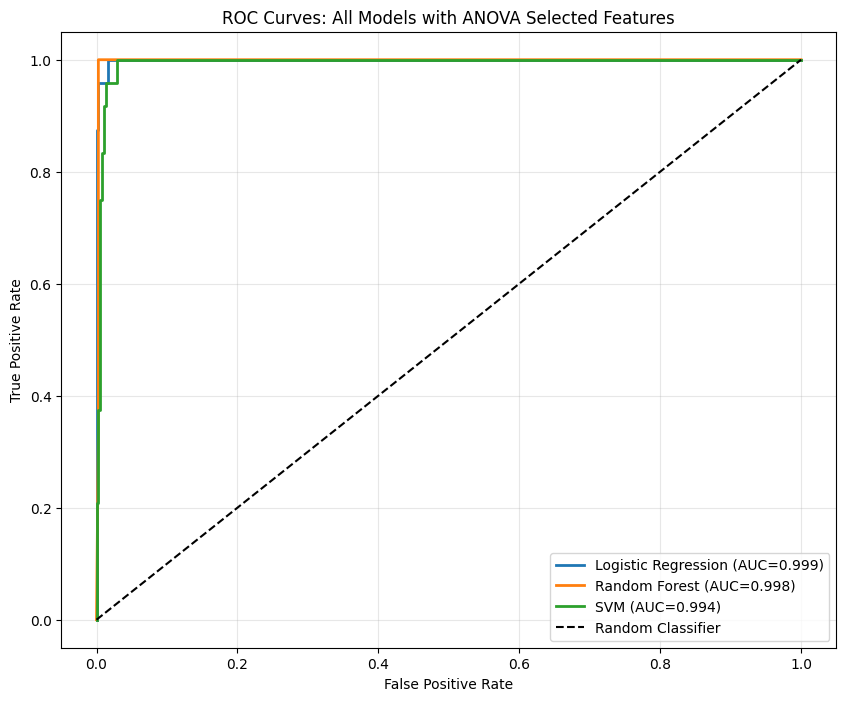

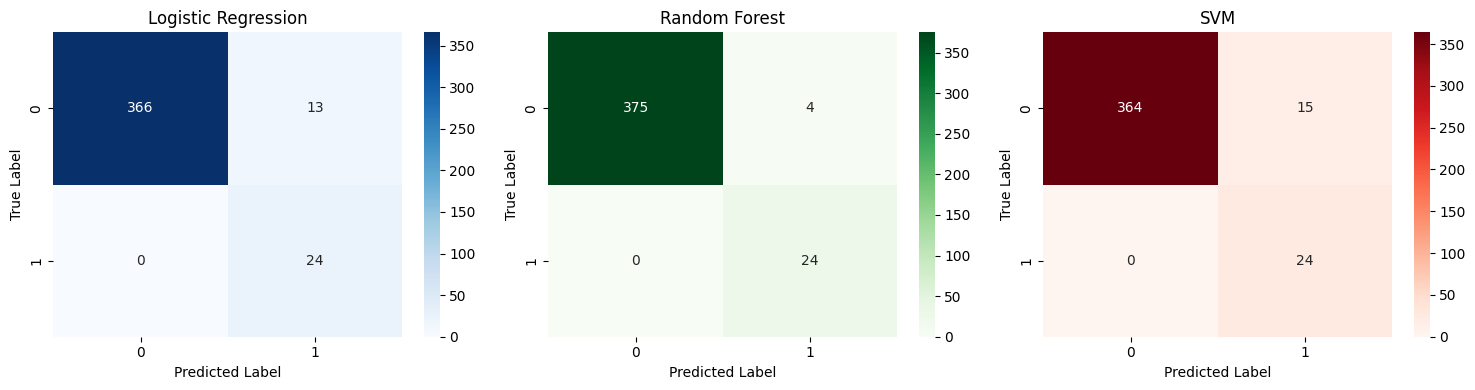

=== PERFORMANCE SUMMARY FOR ALL MODELS WITH ANOVA FEATURES ===
                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression    0.9677     0.6486     1.0    0.7869  0.9991
1        Random Forest    0.9901     0.8571     1.0    0.9231  0.9978
2                  SVM    0.9628     0.6154     1.0    0.7619  0.9943

=== CLASS DISTRIBUTION ANALYSIS ===
Original distribution:
target_binary
0    1890
1     122
Name: count, dtype: int64

After SMOTE (training set):
target_binary
0    1511
1    1511
Name: count, dtype: int64


In [31]:
# ROC Curve Comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr_anova, tpr_lr_anova, label=f'Logistic Regression (AUC={roc_auc_lr_anova:.3f})', linewidth=2)
plt.plot(fpr_rf_anova, tpr_rf_anova, label=f'Random Forest (AUC={roc_auc_rf_anova:.3f})', linewidth=2)
plt.plot(fpr_svm_anova, tpr_svm_anova, label=f'SVM (AUC={roc_auc_svm_anova:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models with ANOVA Selected Features')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
   
# LR Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# RF Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# SVM Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title('SVM')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Performance Summary Table
performance_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr_anova),
                accuracy_score(y_test, y_pred_rf_anova),
                accuracy_score(y_test, y_pred_svm_anova)],
    'Precision': [precision_score(y_test, y_pred_lr_anova),
                 precision_score(y_test, y_pred_rf_anova),
                 precision_score(y_test, y_pred_svm_anova)],
    'Recall': [recall_score(y_test, y_pred_lr_anova),
              recall_score(y_test, y_pred_rf_anova),
              recall_score(y_test, y_pred_svm_anova)],
    'F1-Score': [f1_score(y_test, y_pred_lr_anova),
                f1_score(y_test, y_pred_rf_anova),
                f1_score(y_test, y_pred_svm_anova)],
    'AUC': [roc_auc_lr_anova, roc_auc_rf_anova, roc_auc_svm_anova]
})

print("=== PERFORMANCE SUMMARY FOR ALL MODELS WITH ANOVA FEATURES ===")
print(performance_summary.round(4))

# Class Distribution Check
print("\n=== CLASS DISTRIBUTION ANALYSIS ===")
print("Original distribution:")
print(y.value_counts())
print("\nAfter SMOTE (training set):")
print(pd.Series(y_train_sm).value_counts())


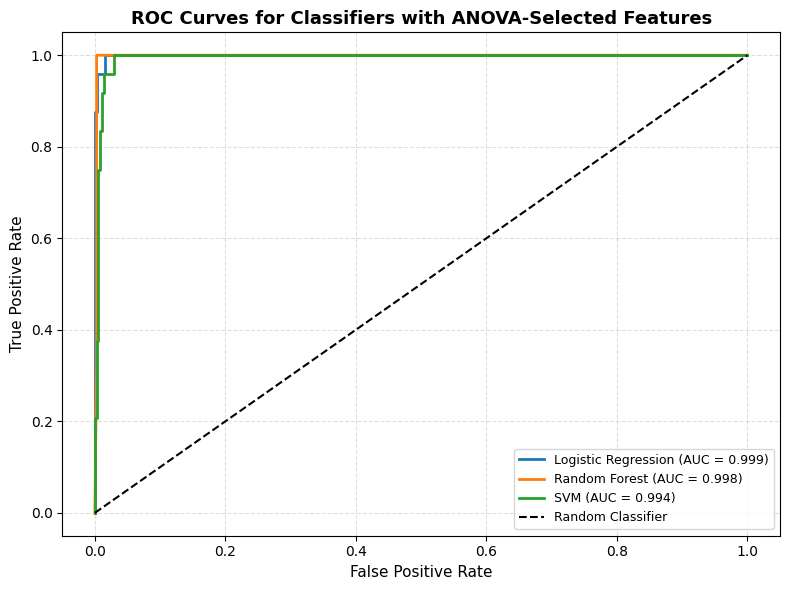

✅ Saved: ROC_Curve_Comparison.png


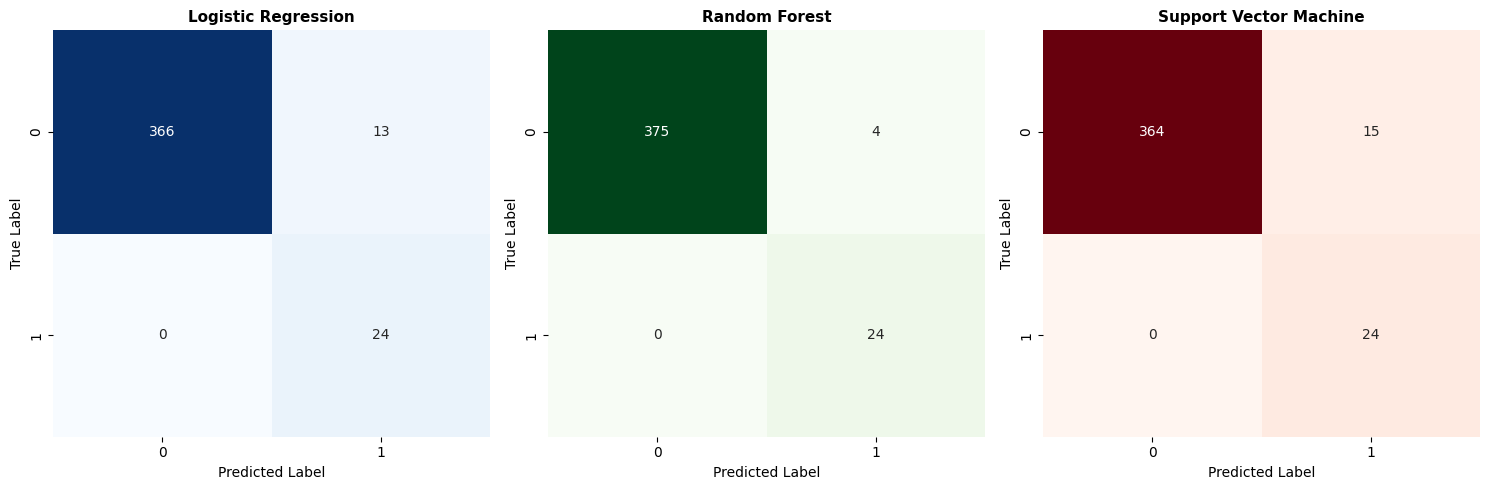

✅ Saved: Confusion_Matrix_All_Models.png


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === ROC Curve Comparison (ANOVA Features) ===
plt.figure(figsize=(8, 6))

# ROC curves for all models
plt.plot(fpr_lr_anova, tpr_lr_anova, label=f'Logistic Regression (AUC = {roc_auc_lr_anova:.3f})', linewidth=2)
plt.plot(fpr_rf_anova, tpr_rf_anova, label=f'Random Forest (AUC = {roc_auc_rf_anova:.3f})', linewidth=2)
plt.plot(fpr_svm_anova, tpr_svm_anova, label=f'SVM (AUC = {roc_auc_svm_anova:.3f})', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Labels and title (important for reviewer comment)
plt.title('ROC Curves for Classifiers with ANOVA-Selected Features', fontsize=13, weight='bold')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)

# Save high-quality image (300 dpi, IEEE standard)
plt.tight_layout()
plt.savefig("ROC_Curve_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ROC_Curve_Comparison.png")


# === Confusion Matrix Visualization (ANOVA Models) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression', fontsize=11, weight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest', fontsize=11, weight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[2], cbar=False)
axes[2].set_title('Support Vector Machine', fontsize=11, weight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=10)
axes[2].set_ylabel('True Label', fontsize=10)

plt.tight_layout()

# Save high-quality combined image
plt.savefig("Confusion_Matrix_All_Models.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: Confusion_Matrix_All_Models.png")


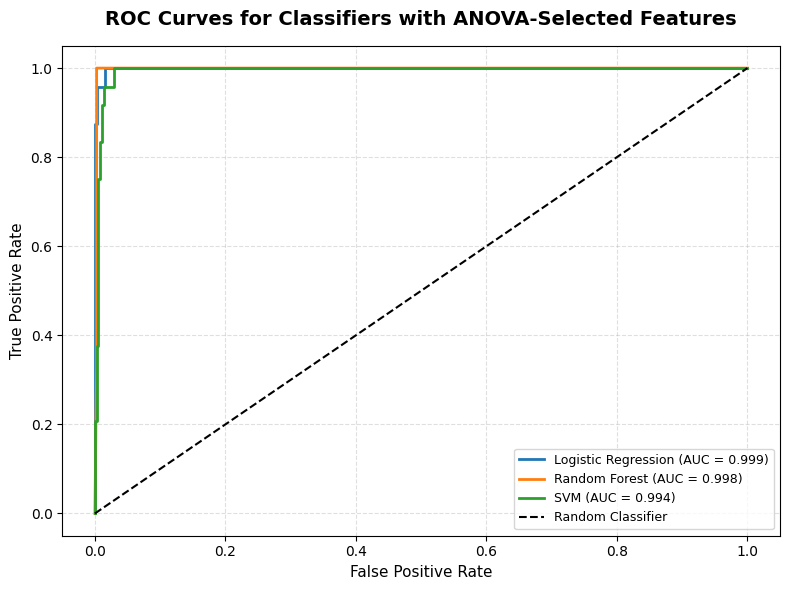

✅ Saved: ROC_Curve_Comparison_Clean.png


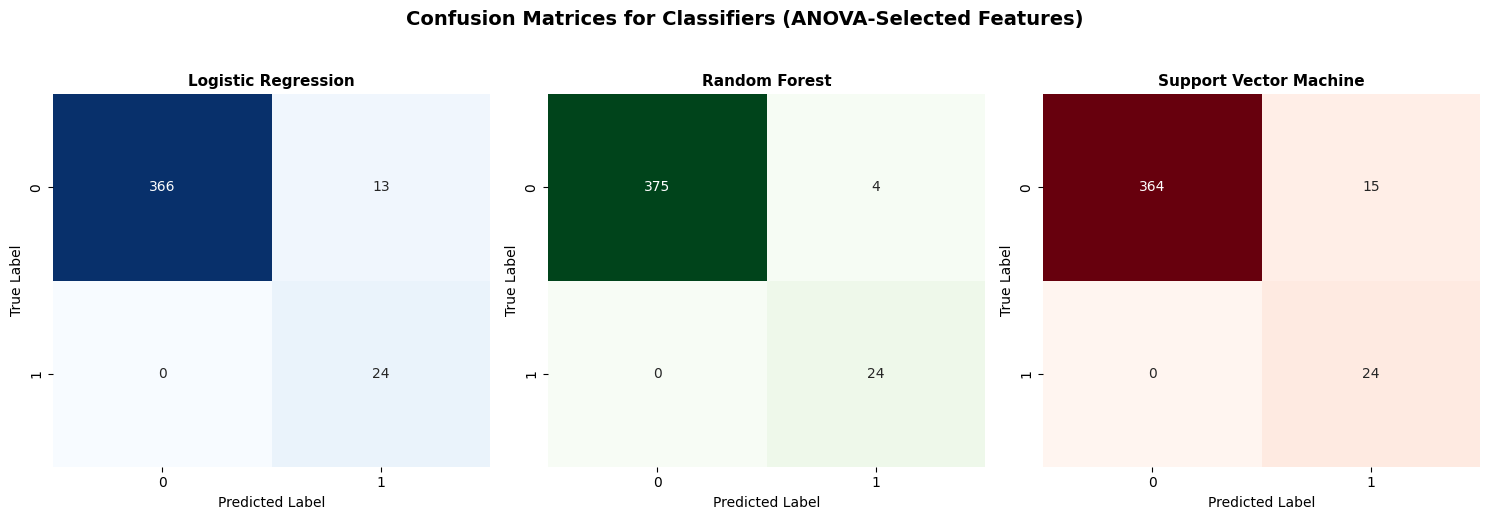

✅ Saved: Confusion_Matrix_All_Models_Clean.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# === ROC Curve Comparison (ANOVA Features) ===
plt.figure(figsize=(8, 6))

# ROC curves for all models
plt.plot(fpr_lr_anova, tpr_lr_anova, label=f'Logistic Regression (AUC = {roc_auc_lr_anova:.3f})', linewidth=2)
plt.plot(fpr_rf_anova, tpr_rf_anova, label=f'Random Forest (AUC = {roc_auc_rf_anova:.3f})', linewidth=2)
plt.plot(fpr_svm_anova, tpr_svm_anova, label=f'SVM (AUC = {roc_auc_svm_anova:.3f})', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Labels and title
plt.title('ROC Curves for Classifiers with ANOVA-Selected Features', fontsize=14, weight='bold', pad=15)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)

# Save high-quality image (IEEE standard)
plt.tight_layout()
plt.savefig("ROC_Curve_Comparison_Clean.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ROC_Curve_Comparison_Clean.png")



# === Confusion Matrix Visualization (ANOVA Models) ===
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices for Classifiers (ANOVA-Selected Features)',
             fontsize=14, weight='bold', y=1.03)

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression', fontsize=11, weight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest', fontsize=11, weight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=10)
axes[1].set_ylabel('True Label', fontsize=10)

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', ax=axes[2], cbar=False)
axes[2].set_title('Support Vector Machine', fontsize=11, weight='bold')
axes[2].set_xlabel('Predicted Label', fontsize=10)
axes[2].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.savefig("Confusion_Matrix_All_Models_Clean.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: Confusion_Matrix_All_Models_Clean.png")


In [34]:
plt.savefig("comparitive-graph.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
